In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/titanic_cleaned.csv')
print("Dataset loaded:", df.shape[0], "passengers")
df.head()

Dataset loaded: 891 passengers


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [3]:
print("Overall survival rate:", round(df['Survived'].mean() * 100, 1), "%")
df.describe()

Overall survival rate: 38.4 %


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


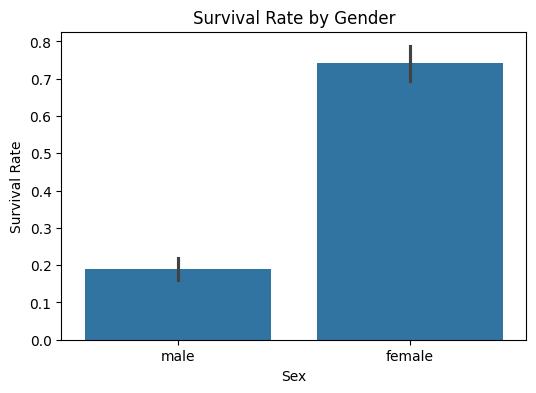

In [4]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
print(gender_survival)

plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.ylabel('Survival Rate')
plt.show()

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64


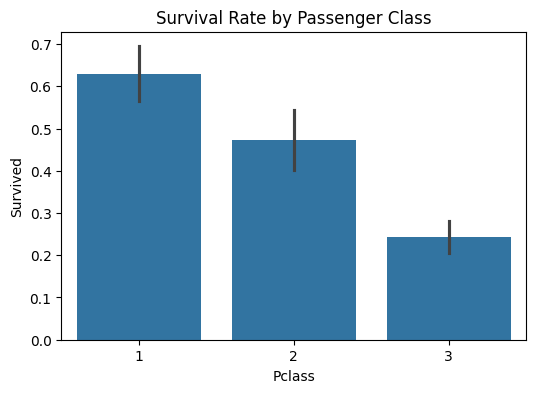

In [5]:
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
print(class_survival)

plt.figure(figsize=(6, 4))
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Survival Rate by Passenger Class')
plt.show()

AgeGroup
Child (0-12)           57.971014
Teen (13-18)           42.857143
Young Adult (19-35)    35.327103
Adult (36-60)          40.000000
Senior (60+)           22.727273
Name: Survived, dtype: float64


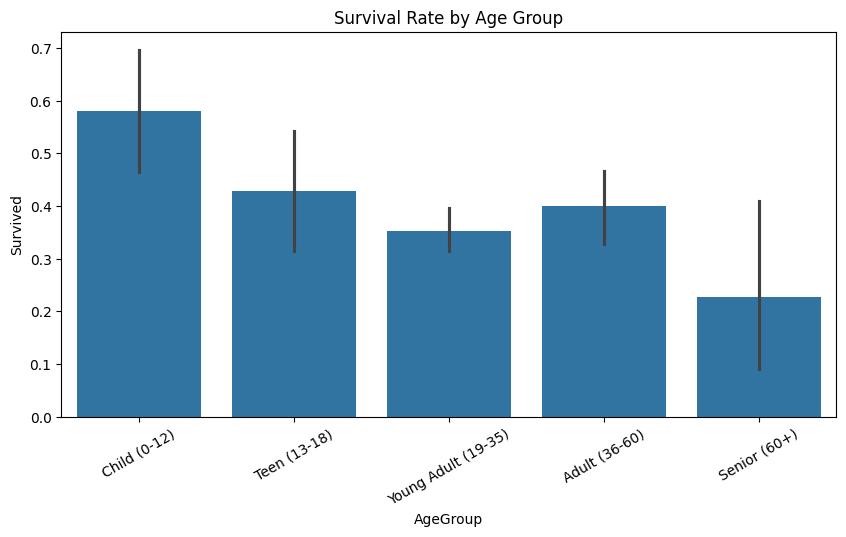

In [6]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (60+)']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_survival = df.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
print(age_survival)

plt.figure(figsize=(10, 5))
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title('Survival Rate by Age Group')
plt.xticks(rotation=30)
plt.show()

FamilyCategory
Alone                 30.353818
Large Family (5+)     16.129032
Small Family (2-4)    57.876712
Name: Survived, dtype: float64


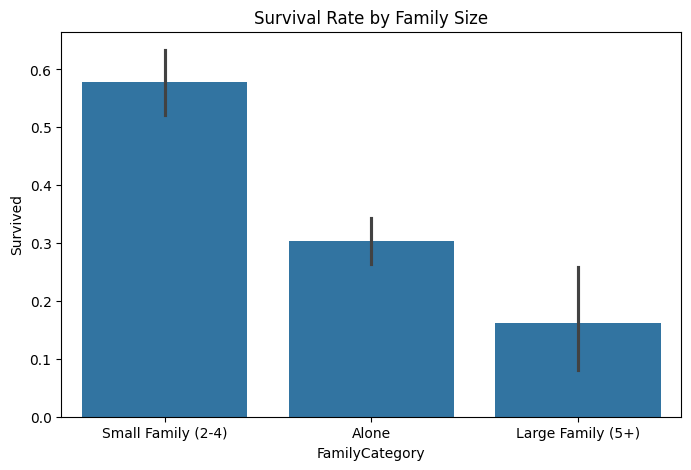

In [7]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

def family_category(size):
    if size == 1:
        return 'Alone'
    elif size <= 4:
        return 'Small Family (2-4)'
    else:
        return 'Large Family (5+)'

df['FamilyCategory'] = df['FamilySize'].apply(family_category)

family_survival = df.groupby('FamilyCategory', observed=True)['Survived'].mean() * 100
print(family_survival)

plt.figure(figsize=(8, 5))
sns.barplot(x='FamilyCategory', y='Survived', data=df)
plt.title('Survival Rate by Family Size')
plt.show()

Average fare - Survived: 48.4
Average fare - Not Survived: 22.12


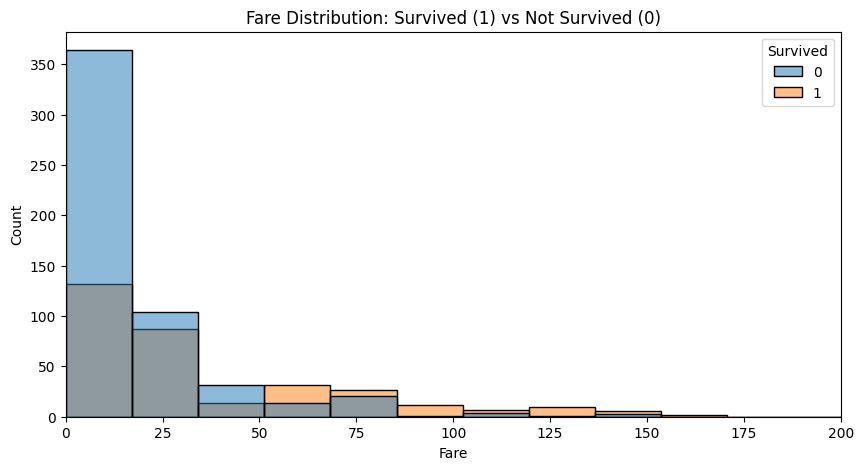

In [8]:
print("Average fare - Survived:", round(df[df['Survived']==1]['Fare'].mean(), 2))
print("Average fare - Not Survived:", round(df[df['Survived']==0]['Fare'].mean(), 2))

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Fare', hue='Survived', bins=30)
plt.title('Fare Distribution: Survived (1) vs Not Survived (0)')
plt.xlim(0, 200)
plt.show()

Embarked
C    55.357143
Q    38.961039
S    33.900929
Name: Survived, dtype: float64


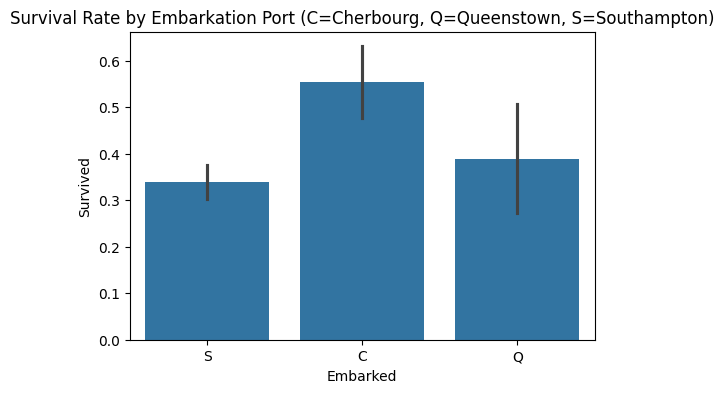

In [9]:
embarked_survival = df.groupby('Embarked')['Survived'].mean() * 100
print(embarked_survival)

plt.figure(figsize=(6, 4))
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Survival Rate by Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.show()

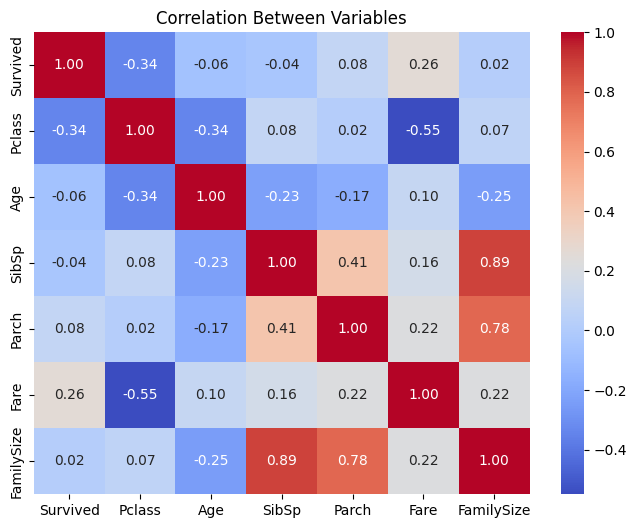

In [10]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Variables')
plt.show()

In [11]:
print("""
============ KEY INSIGHTS SUMMARY ============
1. GENDER: Women survived ~74% vs men ~19% — the strongest factor.
2. CLASS: 1st class ~63% vs 3rd class ~24% — wealth mattered.
3. AGE: Children (0-12) were prioritized during evacuation.
4. FAMILY: Small families (2-4) survived best; large families (5+) worst.
5. FARE: Survivors paid double the average fare of non-survivors.
6. EMBARKED (Bonus): Cherbourg passengers had the highest survival rate.

MODEL IMPLICATION: Sex, Pclass, Fare, and FamilySize
should be the most important features for predicting survival.
=============================================
""")


============ KEY INSIGHTS SUMMARY ============
1. GENDER: Women survived ~74% vs men ~19% — the strongest factor.
2. CLASS: 1st class ~63% vs 3rd class ~24% — wealth mattered.
3. AGE: Children (0-12) were prioritized during evacuation.
4. FAMILY: Small families (2-4) survived best; large families (5+) worst.
5. FARE: Survivors paid double the average fare of non-survivors.
6. EMBARKED (Bonus): Cherbourg passengers had the highest survival rate.

MODEL IMPLICATION: Sex, Pclass, Fare, and FamilySize
should be the most important features for predicting survival.

